<div style="background: linear-gradient(135deg, #1e1b4b, #312e81); color:white; padding:25px; border-radius:10px; 
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;"> WikiArt Image Classification</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#a5b4fc;">
    Transfer Learning with VGG16
  </h3>

  <hr style="width:60%; border:1px solid #6366f1; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Deep Learning (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#c7d2fe;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e0e7ff; padding:15px 20px; border-left:5px solid #6366f1; 
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">

  <b>Notebook Description</b><br>
  Transfer learning approach using a VGG16 backbone pretrained on ImageNet, 
  fine-tuned for artist classification on the WikiArt dataset. 
  The model is evaluated using macro F1 score to account for class imbalance across the 23 artist categories.

</div>

<br>

**<h3>Table of Contents</h3>**
* [1. Environment Setup](#1-environment-setup)
* [2. Model Implementation](#2-model)
* [3. Model Evaluation](#3-eval)

<div id="1-environment-setup" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    1. Setup
  </h2>
</div>

In [10]:
import os
import sys
import yaml
import tensorflow as tf
import keras
from keras import layers

# import utils functions auto-reload
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath('../src'))

from utils import (
    evaluate_model,
    load_datasets,
    plot_learning_curves,
    save_history,
    class_weights,
    set_seeds,
    predict_tta,
)

from GPUGuard import GPUGuard
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load config (relative to notebooks/)
with open('../config.yml', 'r') as f:
    config = yaml.safe_load(f)

SEED = config['seed']
set_seeds(SEED)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<div id="2-model" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    2. Model Implementation
  </h2>
</div>

## 2.1 Transfer Learning using VGG16

In [11]:
IMG_SIZE = config['img_size']
BATCH_SIZE = 16
NUM_CLASSES = config['num_classes']
MAX_EPOCHS = config['max_epochs']

# Set paths (relative to notebooks/)
train_dir = config['paths']['train_dir']
val_dir   = config['paths']['val_dir']
test_dir  = config['paths']['test_dir']

# Load datasets
train_ds, val_ds, test_ds, class_names = load_datasets(
    train_dir, val_dir, test_dir,
    img_size=IMG_SIZE, batch_size=BATCH_SIZE
     )

# prefetch datasets for performance
autotune = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=autotune)
val_ds = val_ds.prefetch(buffer_size=autotune)
test_ds = test_ds.prefetch(buffer_size=autotune)

# compute class weights from training dataset
cw = class_weights(train_ds)

# callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_f1_macro",
        mode="max",
        patience=4,
        min_delta=0.002,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_f1_macro",
        mode="max",
        factor=0.5,
        patience=2,
        min_delta=0.002,
        min_lr=1e-7,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=config['models']['vgg16']['checkpoint'],
        monitor="val_f1_macro",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    GPUGuard(max_usage_ratio=0.95)
]

Found 9282 files belonging to 23 classes.
Found 1980 files belonging to 23 classes.
Found 2012 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [12]:
# --- Data Augmentation ---
data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05, fill_mode="nearest"),
        layers.RandomZoom(0.1),
        layers.RandomBrightness(0.1),
        layers.RandomContrast(0.1),
    ], name='data_augmentation')

# --- Build Model ---
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False  # freeze backbone

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)  # VGG16 normalization for ImageNet pretrained weights
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="vgg16_transfer")
model.summary()

Model: "vgg16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 23)        │      5,911 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,851,927 (56.66 MB)

 Trainable params: 137,239 (536.09 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [13]:
# --- Train (Phase 1 — frozen backbone) ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

# Save model in models directory (relative to notebooks/)

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    class_weight = cw
)

Epoch 1/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1787 - f1_macro: 0.1670 - loss: 3.7667
Epoch 1: val_f1_macro improved from None to 0.44107, saving model to ../models/vgg16_best.keras

Epoch 1: finished saving model to ../models/vgg16_best.keras
581/581 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.2627 - f1_macro: 0.2467 - loss: 2.7845 - val_accuracy: 0.4854 - val_f1_macro: 0.4411 - val_loss: 1.7496 - learning_rate: 0.0010
Epoch 2/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4012 - f1_macro: 0.3846 - loss: 2.0035
Epoch 2: val_f1_macro improved from 0.44107 to 0.52856, saving model to ../models/vgg16_best.keras

Epoch 2: finished saving model to ../models/vgg16_best.keras
581/581 ━━━━━━━━━━━━━━━━━━━━ 32s 55ms/step - accuracy: 0.4289 - f1_macro: 0.4133 - loss: 1.9303 - val_accuracy: 0.5505 - val_f1_macro: 0.5286 - val_loss: 1.5569 - learning_rate: 0.0010
Epoch 3/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4402 - f1_macro: 0.4264 - los

In [14]:
 # Stop earlier attempting to avoid overfit
callbacksPhase2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_f1_macro",
        mode="max",
        patience=3,
        min_delta=0.002,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_f1_macro",
        mode="max",
        factor=0.3,
        patience=2,
        min_delta=0.002,
        min_lr=1e-7,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=config['models']['vgg16']['checkpoint'],
        monitor="val_f1_macro",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    GPUGuard(max_usage_ratio=0.95)
]

In [15]:
# --- Phase 2: Fine-tuning ---

# Unfreeze the last block of VGG16
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Recompile with very low LR to avoid destroying pretrained weights
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacksPhase2,
    class_weight = cw
)

Epoch 1/100


581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7010 - f1_macro: 0.6973 - loss: 0.9343
Epoch 1: val_f1_macro improved from None to 0.64471, saving model to ../models/vgg16_best.keras

Epoch 1: finished saving model to ../models/vgg16_best.keras
581/581 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.6977 - f1_macro: 0.6951 - loss: 0.9159 - val_accuracy: 0.6657 - val_f1_macro: 0.6447 - val_loss: 1.4004 - learning_rate: 1.0000e-05
Epoch 2/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6998 - f1_macro: 0.6960 - loss: 0.8848
Epoch 2: val_f1_macro improved from 0.64471 to 0.64804, saving model to ../models/vgg16_best.keras

Epoch 2: finished saving model to ../models/vgg16_best.keras
581/581 ━━━━━━━━━━━━━━━━━━━━ 32s 55ms/step - accuracy: 0.7080 - f1_macro: 0.7046 - loss: 0.8623 - val_accuracy: 0.6712 - val_f1_macro: 0.6480 - val_loss: 1.3614 - learning_rate: 1.0000e-05
Epoch 3/100
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7286 - f1_macro: 0.7260 - loss: 0

In [16]:
test_loss, test_accuracy, test_f1, _ , _ ,_  = predict_tta(model, test_ds)
print(f"TTA Results - Loss: {test_loss:.4f} | Accuracy: {test_accuracy:.4f} | F1: {test_f1:.4f}")

TTA Results - Loss: 1.4211 | Accuracy: 0.7356 | F1: 0.7211
TTA Results - Loss: 1.4211 | Accuracy: 0.7356 | F1: 0.7211


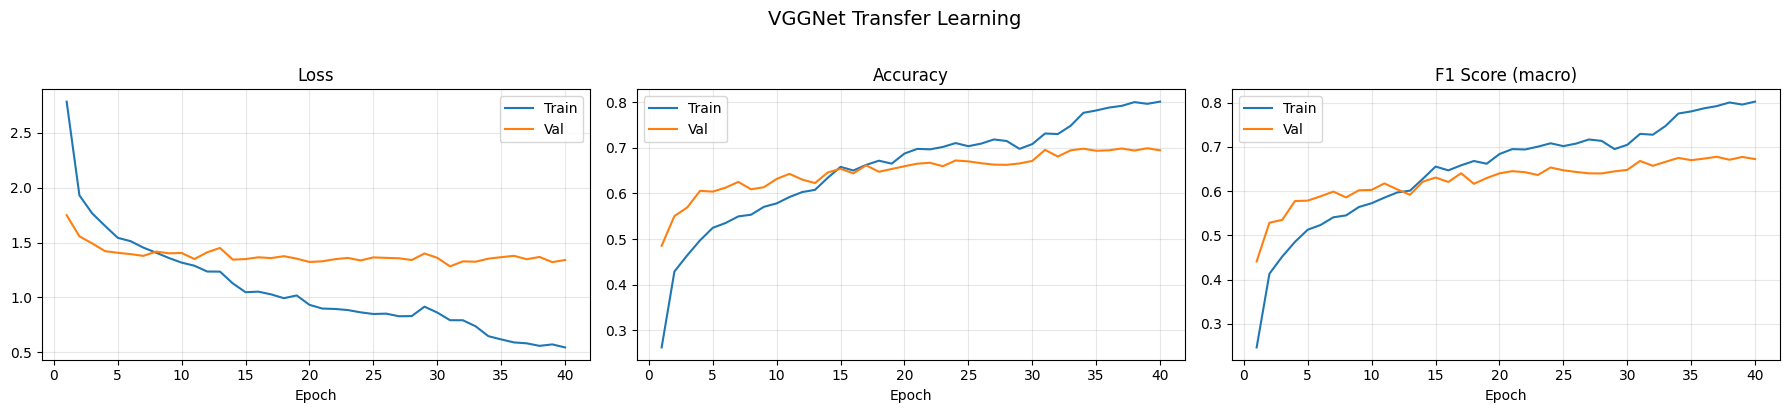

Best epoch (lowest val_loss): 31
  Val Loss: 1.2831
  Val Acc:  0.6955
  Val F1:   0.6682


In [17]:
plot_learning_curves([history_phase1, history_phase2], title="VGGNet Transfer Learning")


  VGG16 Transfer Learning - Test Evaluation
  Test Loss:     1.4211
  Test Accuracy: 0.6968
  Test F1 Macro: 0.6836

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.83      0.77      0.80        87
      Boris_Kustodiev       0.58      0.39      0.46        67
     Camille_Pissarro       0.55      0.77      0.64        93
        Childe_Hassam       0.44      0.55      0.49        58
         Claude_Monet       0.70      0.56      0.62       141
          Edgar_Degas       0.78      0.69      0.73        65
        Eugene_Boudin       0.81      0.81      0.81        59
         Gustave_Dore       0.79      0.96      0.87        80
           Ilya_Repin       0.55      0.62      0.58        58
      Ivan_Aivazovsky       0.84      0.89      0.86        61
        Ivan_Shishkin       0.76      0.71      0.74        55
  John_Singer_Sargent       0.72      0.63      0.67        83
         Marc_Chagall       0.83      0

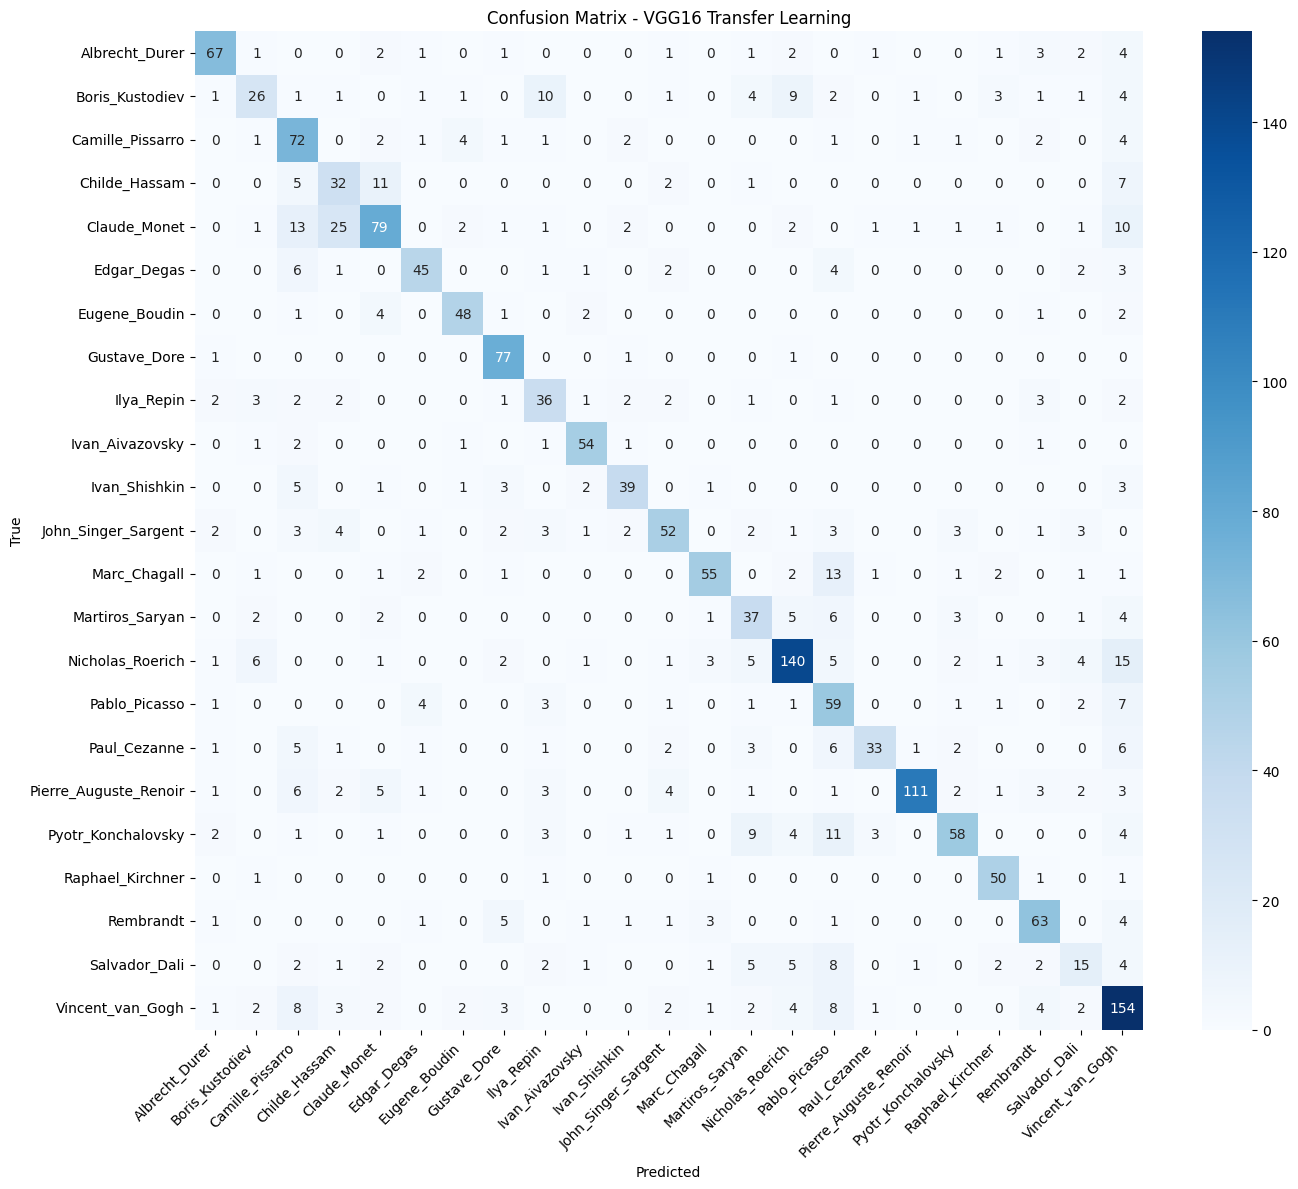

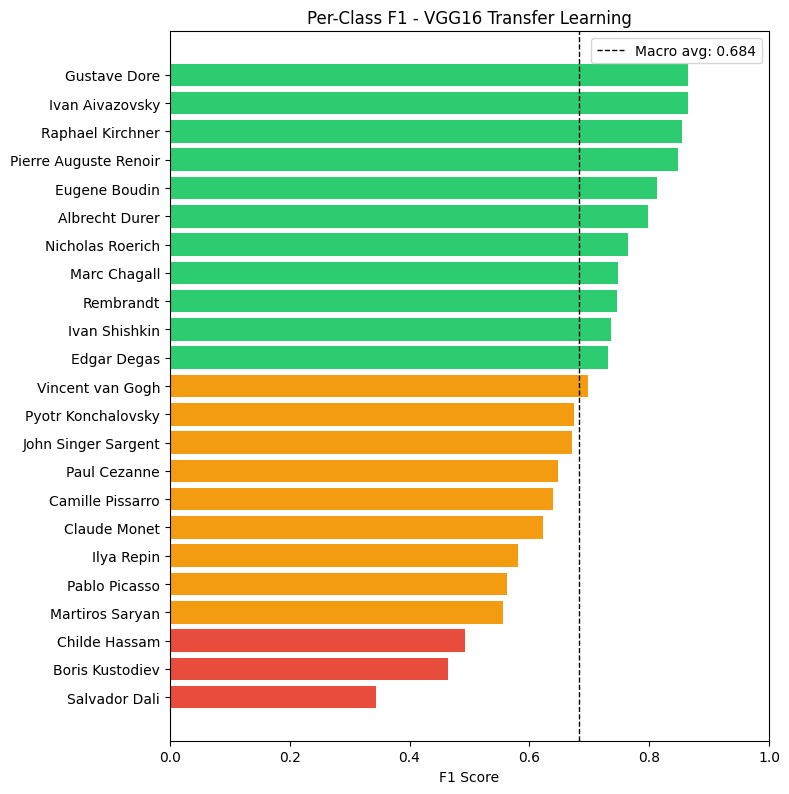

In [18]:
metrics_vgg16 = evaluate_model(model, test_ds, class_names, "VGG16 Transfer Learning")

In [19]:
save_history([history_phase1, history_phase2], config['models']['vgg16']['history'])

History saved to ../models/vgg16_history.json
